<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/TradingStrategies/TradingStrategies/Factor_Investing_Strategy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

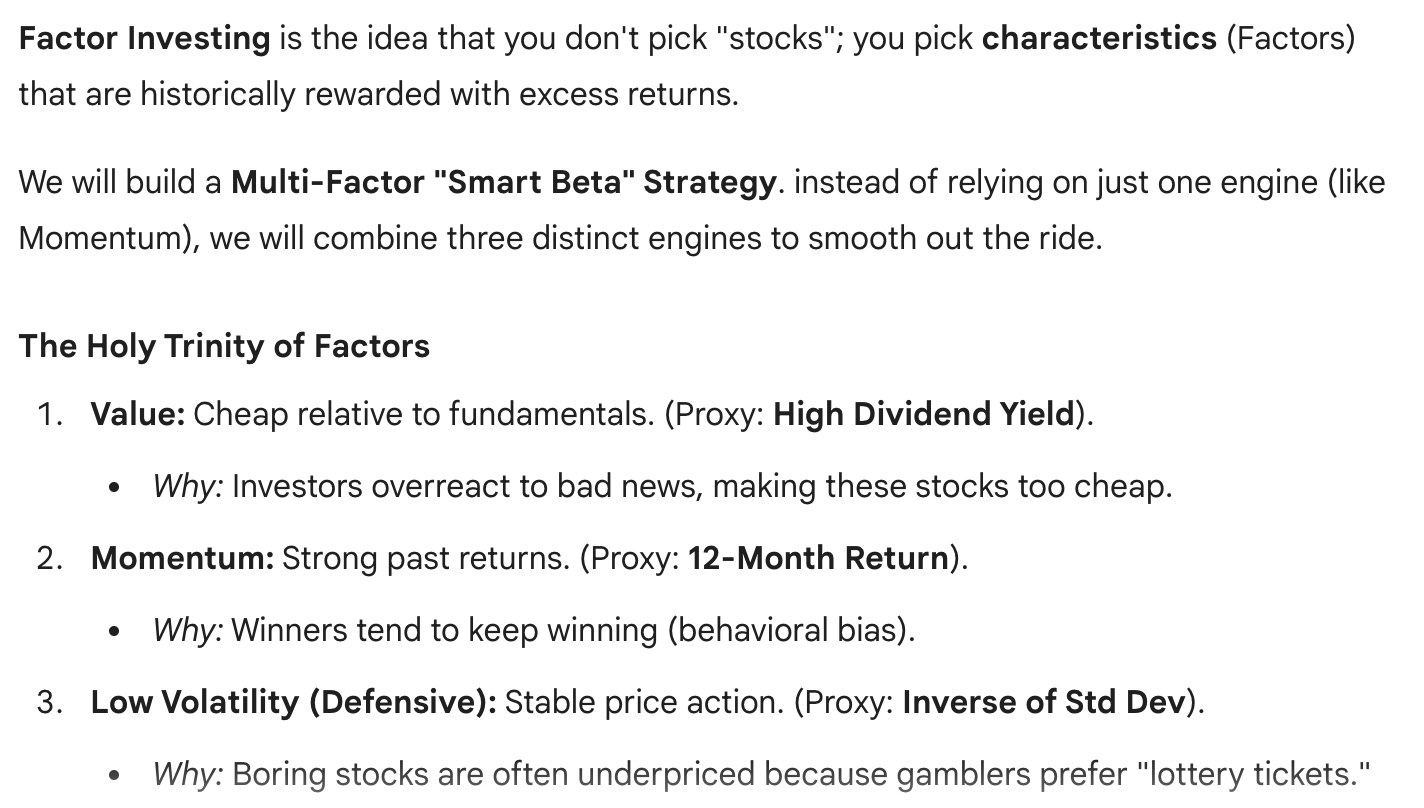

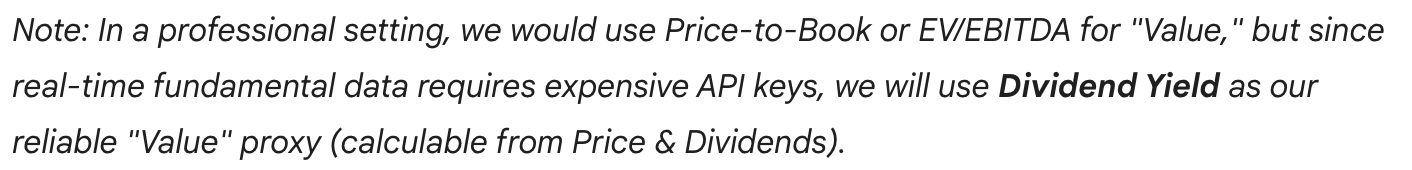

In [12]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# --- CONFIGURATION ---
# A subset of Dow 30 + Tech + Defensive for diversity
tickers = [
    'AAPL', 'MSFT', 'JPM', 'JNJ', 'V', 'PG', 'XOM', 'HD', 'CVX', 'MRK',
    'KO', 'PEP', 'ABBV', 'COST', 'MCD', 'WMT', 'CSCO', 'BAC', 'VZ', 'INTC'
]
benchmark_ticker = 'SPY'

start_date = '2015-01-01'
end_date = '2024-01-01'

In [4]:
print("📥 Downloading Universe Data...")
# We need 'Adj Close' for Returns and 'Dividends' for Value Proxy
data = yf.download(tickers, start=start_date, end=end_date, actions=True, progress=False, auto_adjust=False)

# Extract Price and Dividends
prices = data['Adj Close']
dividends = data['Dividends']

# Resample to Monthly (Factor investing is slow, we don't day trade it)
monthly_prices = prices.resample('M').last()
monthly_divs = dividends.resample('M').sum() # Sum dividends paid in that month

print(f"✅ Data Ready. Shape: {monthly_prices.shape}")
monthly_prices.head()

📥 Downloading Universe Data...
✅ Data Ready. Shape: (108, 20)


/tmp/ipython-input-3771187043.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_prices = prices.resample('M').last()
/tmp/ipython-input-3771187043.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_divs = dividends.resample('M').sum() # Sum dividends paid in that month


Ticker,AAPL,ABBV,BAC,COST,CSCO,CVX,HD,INTC,JNJ,JPM,KO,MCD,MRK,MSFT,PEP,PG,V,VZ,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,
2015-01-31,25.973396,38.531803,12.021519,115.248276,18.824930,63.941956,80.666718,25.349258,73.730705,40.474880,29.097834,70.049088,40.864105,34.437160,67.410141,62.435986,59.000938,25.725536,22.970552,54.541592
2015-02-28,28.590910,38.627575,12.545229,122.666039,21.066505,67.183716,88.646835,25.693357,76.003975,45.610538,30.603268,75.595650,39.684551,37.643959,71.147995,63.058178,62.910984,27.830393,22.686733,55.656162
2015-03-31,27.693964,37.376167,12.250147,126.455536,19.803438,66.113106,88.217796,24.163345,74.587845,45.089535,28.897446,74.479675,39.281300,34.905434,69.193359,60.695259,60.668743,27.368917,22.366161,53.430931
2015-04-30,27.854212,41.626030,12.679978,119.729073,20.738581,69.942078,83.069618,25.152441,73.549843,47.397205,28.904568,73.799385,40.702751,41.756035,68.831551,59.368996,61.262348,28.708050,21.224060,54.920700
2015-05-31,29.117090,42.868496,13.133682,119.344070,21.083862,65.512527,86.517242,26.820915,74.788216,49.285290,29.189623,73.962677,41.611660,40.489399,69.779510,58.532719,63.813179,28.138897,20.323620,53.999611


In [5]:
# --- FACTOR CALCULATION ENGINE ---

# 1. MOMENTUM (12-Month Return, skipping most recent month to avoid reversal)
momentum = monthly_prices.pct_change(12).shift(1) # Simple 12M Return

# 2. LOW VOLATILITY (Inverse of 12-Month Standard Deviation)
# Calculate daily returns, then rolling std dev, then resample to monthly
daily_rets = prices.pct_change()
volatility = daily_rets.rolling(252).std().resample('M').last()
# Invert: We want LOW vol to be a HIGH score
low_vol = 1.0 / volatility

/tmp/ipython-input-4106068284.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  volatility = daily_rets.rolling(252).std().resample('M').last()


In [6]:
# 3. VALUE (Rolling 12-Month Dividend Yield)
# Sum dividends over last 12 months / Current Price
rolling_divs = monthly_divs.rolling(12).sum()
value_factor = rolling_divs / monthly_prices

# --- NORMALIZATION (Z-SCORE) ---
# (Score - Mean) / StdDev -> Across the Cross-Section (Row-wise)
def z_score(df):
    return df.sub(df.mean(axis=1), axis=0).div(df.std(axis=1), axis=0)

z_mom = z_score(momentum)
z_vol = z_score(low_vol)
z_val = z_score(value_factor)

In [7]:
# --- COMPOSITE SCORE ---
# Weighted Average: 40% Value, 40% Momentum, 20% Low Vol
# (You can tweak these weights based on your view!)
multi_factor_score = (0.4 * z_val) + (0.4 * z_mom) + (0.2 * z_vol)

# Visualize the Rank for a specific date
print("📊 Sample Ranking (Latest Date):")
print(multi_factor_score.iloc[-1].sort_values(ascending=False).head(5))

📊 Sample Ranking (Latest Date):
Ticker
VZ      1.110968
KO      0.218023
INTC    0.213399
MSFT    0.202105
PG      0.177682
Name: 2023-12-31 00:00:00, dtype: float64


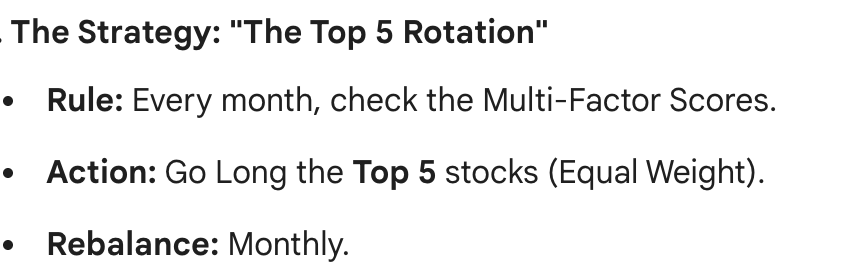

In [8]:
# --- BACKTEST ENGINE ---

portfolio_returns = []
positions_history = []

# Start after 12 months (need data for lookback)
for date in multi_factor_score.index[12:]:

    # 1. Get Scores for this month
    current_scores = multi_factor_score.loc[date]

    # 2. Select Top 5 Tickers
    top_5 = current_scores.sort_values(ascending=False).head(5).index.tolist()
    positions_history.append(top_5)

    # 3. Calculate Return for the NEXT month
    # We assume we hold these Top 5 for the next month
    next_month_idx = multi_factor_score.index.get_loc(date) + 1
    if next_month_idx < len(multi_factor_score):
        # Calculate return of these stocks in the next period
        next_date = multi_factor_score.index[next_month_idx]

        # Simple Return: (Price_Next / Price_Current) - 1
        # We take the mean return of the 5 stocks (Equal Weight)
        p_current = monthly_prices.loc[date, top_5]
        p_next = monthly_prices.loc[next_date, top_5]

        monthly_ret = (p_next / p_current - 1).mean()
        portfolio_returns.append({'Date': next_date, 'Return': monthly_ret})

In [10]:
# Create DataFrame
strat_df = pd.DataFrame(portfolio_returns).set_index('Date')
strat_df['Cumulative'] = (1 + strat_df['Return']).cumprod()

# --- BENCHMARK COMPARISON ---
spy = yf.download('SPY', start=start_date, end=end_date, progress=False, auto_adjust=False)['Adj Close']
spy_monthly = spy.resample('M').last().pct_change()
spy_cum = (1 + spy_monthly.loc[strat_df.index]).cumprod()

/tmp/ipython-input-374616218.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  spy_monthly = spy.resample('M').last().pct_change()


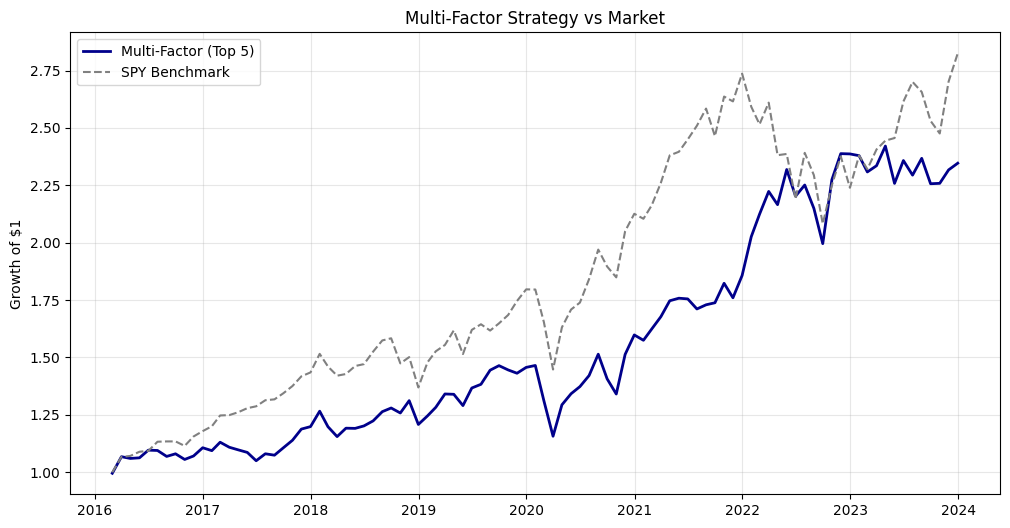

In [11]:
# Plot
plt.figure(figsize=(12, 6))
plt.plot(strat_df['Cumulative'], label='Multi-Factor (Top 5)', color='darkblue', linewidth=2)
plt.plot(spy_cum, label='SPY Benchmark', color='gray', linestyle='--')
plt.title("Multi-Factor Strategy vs Market")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [21]:
# Fix: Use .squeeze() to ensure 1D shape or select the column explicitly
market_data = spy_monthly.loc[strat_df.index]

# Handle cases where it's a DataFrame (N, 1) or Series (N,)
if isinstance(market_data, pd.DataFrame):
    market_data = market_data.iloc[:, 0] # Select first column

audit_df = pd.DataFrame({
    'Strat': strat_df['Return'],
    'Market': market_data
}).dropna()

audit_df.head()

,Strat,Market
Date,,
2016-02-29,-0.005039,-0.000826
2016-03-31,0.072615,0.067266
2016-04-30,-0.007081,0.003941
2016-05-31,0.002508,0.017011
2016-06-30,0.031449,0.003476


In [22]:
# 1. Basic Alpha/Beta
slope, intercept, r, p, err = stats.linregress(audit_df['Market'], audit_df['Strat'])

print("📊 FACTOR STRATEGY AUDIT (Fixed)")
print(f"------------------------")
print(f"Total Return:       {(strat_df['Cumulative'].iloc[-1]-1)*100:.2f}%")
print(f"Alpha (Annualized): {intercept*12*100:.2f}%")
print(f"Beta (vs SPY):      {slope:.2f}")
print(f"Correlation:        {r:.2f}")

📊 FACTOR STRATEGY AUDIT (Fixed)
------------------------
Total Return:       134.62%
Alpha (Annualized): 1.98%
Beta (vs SPY):      0.69
Correlation:        0.72


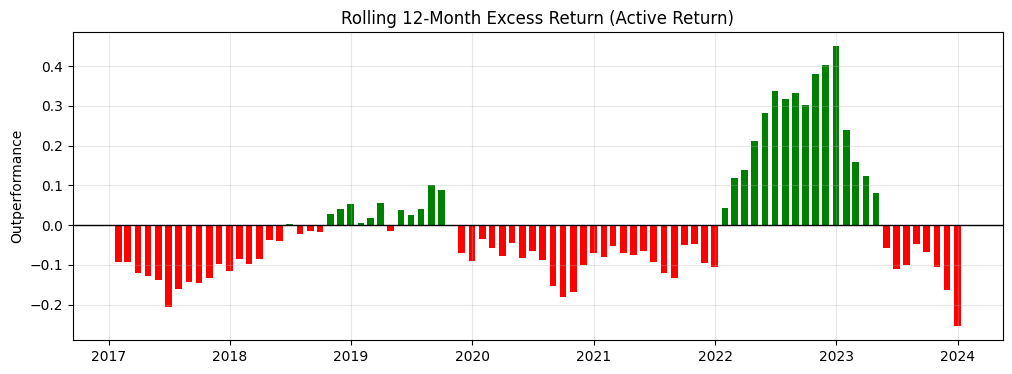

In [23]:
# 2. Rolling Alpha Check
rolling_alpha = (audit_df['Strat'] - audit_df['Market']).rolling(12).sum()

plt.figure(figsize=(12, 4))
plt.bar(rolling_alpha.index, rolling_alpha, color=np.where(rolling_alpha>0, 'green', 'red'), width=20)
plt.axhline(0, color='black', linewidth=1)
plt.title("Rolling 12-Month Excess Return (Active Return)")
plt.ylabel("Outperformance")
plt.grid(True, alpha=0.3)
plt.show()